# Day 08 — Linear Algebra I: Vectors and Vector Spaces
### Task 01: Visualise 2D vectors and their arithmetic

**Rule for today: draw before you compute.** Every plot below comes before any "just trust the math" moment.

## Step 0 — Imports

We only need `numpy` for vector math and `matplotlib` for plotting. Both are already installed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Step 1 — The `draw()` helper

**Why `quiver` needs `angles='xy', scale_units='xy', scale=1`:**
`quiver` was built for wind/vector-field plots, not literal coordinate arrows. By default it
auto-scales arrow length to "look nice" on the axes, using its own angle convention — so a
vector `(6, 8)` might render the same visual length as `(3, 4)`, which defeats the point of
seeing vectors geometrically. Setting:
- `angles='xy'` → compute the arrow's angle from actual (x, y) data.
- `scale_units='xy'` + `scale=1` → 1 data unit = 1 arrow-length unit, no auto-rescaling.

Without these three, the picture would lie about relative length and direction.

In [2]:
def draw(vectors, labels, colors=None, title="Vectors"):
    """
    Draw a list of 2D vectors as arrows from the origin.

    vectors: list of (x, y) tuples/arrays
    labels:  list of strings, one per vector
    colors:  optional list of matplotlib colors, one per vector
    """
    fig, ax = plt.subplots(figsize=(5, 5))

    if colors is None:
        colors = plt.cm.tab10.colors  # cycle through a colormap if not given

    all_x = [v[0] for v in vectors] + [0]
    all_y = [v[1] for v in vectors] + [0]
    limit = max(max(abs(min(all_x)), abs(max(all_x))),
                max(abs(min(all_y)), abs(max(all_y)))) + 1

    for i, (v, l) in enumerate(zip(vectors, labels)):
        c = colors[i % len(colors)]
        ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                   color=c, width=0.008)
        # label near the arrow tip
        ax.text(v[0] * 1.05, v[1] * 1.05, l, fontsize=12, color=c)

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.set_title(title)
    plt.show()

## Step 2 — Draw three vectors of your choice

Pick three arbitrary 2D vectors and confirm the helper labels and scales them correctly.

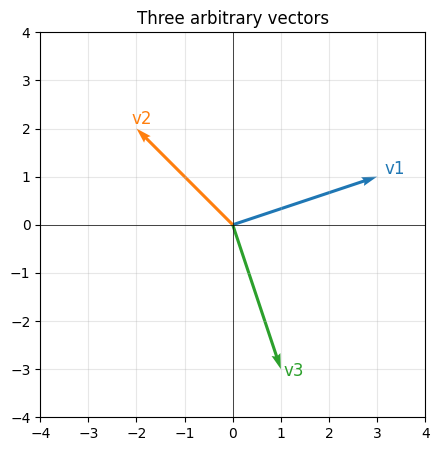

In [3]:
v1 = np.array([3, 1])
v2 = np.array([-2, 2])
v3 = np.array([1, -3])

draw([v1, v2, v3], ["v1", "v2", "v3"], title="Three arbitrary vectors")

## Step 3 — a, b, and a + b: addition is tip-to-tail

**Concept:** `a + b` means "walk along `a`, then walk along `b` starting from where `a` left
off." Geometrically, that's the classic tip-to-tail construction: place `b`'s tail at `a`'s
tip, and the sum is the arrow from the origin straight to `b`'s new tip.

To *see* the tip-to-tail step (not just the final resultant from the origin), we draw an extra
faint arrow representing `b` translated to start at `a`'s tip.

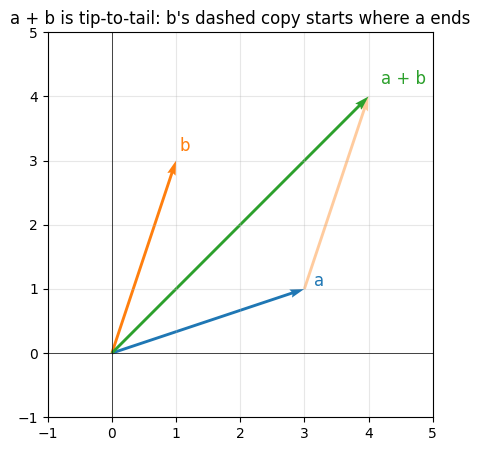

a + b = [4 4]


In [4]:
a = np.array([3, 1])
b = np.array([1, 3])
s = a + b

fig, ax = plt.subplots(figsize=(5, 5))

# a, from origin
ax.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='tab:blue')
ax.text(a[0]*1.05, a[1]*1.05, "a", color='tab:blue', fontsize=12)

# b, from origin (for reference)
ax.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='tab:orange')
ax.text(b[0]*1.05, b[1]*1.05, "b", color='tab:orange', fontsize=12)

# b translated to start at a's tip -- the tip-to-tail step
ax.quiver(a[0], a[1], b[0], b[1], angles='xy', scale_units='xy', scale=1,
          color='tab:orange', alpha=0.4, linestyle='dashed')

# a + b, from origin
ax.quiver(0, 0, s[0], s[1], angles='xy', scale_units='xy', scale=1, color='tab:green')
ax.text(s[0]*1.05, s[1]*1.05, "a + b", color='tab:green', fontsize=12)

lim = max(abs(s).max(), abs(a).max(), abs(b).max()) + 1
ax.set_xlim(-1, lim); ax.set_ylim(-1, lim)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title("a + b is tip-to-tail: b's dashed copy starts where a ends")
plt.show()

# Confirm numerically what the picture shows
print("a + b =", s)

**What the plot confirms:** the solid green arrow (`a + b`, from the origin) lands exactly
on the tip of the dashed orange arrow (`b`, translated to start at `a`'s tip). That's the
whole geometric definition of vector addition — no formula needed to "believe" it, you can see
the tip-to-tail chain land on the sum.

## Step 4 — a, 2a, and -a: what scaling does

**Concept:** multiplying a vector by a scalar `k` stretches (or shrinks) it by a factor of
`|k|`, and:
- if `k > 0` → direction stays the same.
- if `k < 0` → direction flips 180°, magnitude scales by `|k|`.
- if `0 < |k| < 1` → shrinks; `|k| > 1` → stretches; `k = 0` → collapses to the origin.

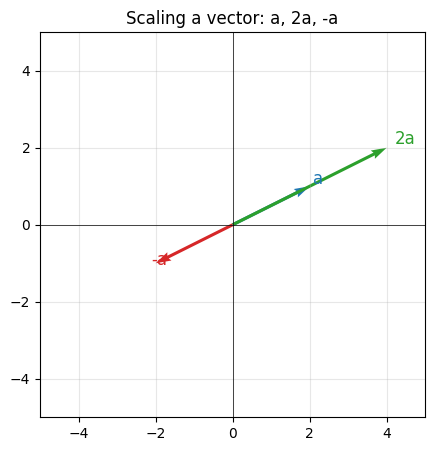

In [5]:
a = np.array([2, 1])

draw([a, 2*a, -a], ["a", "2a", "-a"], colors=['tab:blue', 'tab:green', 'tab:red'],
     title="Scaling a vector: a, 2a, -a")

# Comment / observation:
# 2a points in the SAME direction as a, but is exactly twice as long (magnitude doubles,
# angle unchanged) -- scaling by a positive number > 1 stretches without rotating.
# -a has the SAME length as a but points in the exact OPPOSITE direction (180 degree flip)
# -- scaling by a negative number reverses direction; |k| still controls length.

## Step 5 — a - b: why it points from b to a

**Concept:** `a - b` is defined as `a + (-b)`. So geometrically: flip `b` around (negate it),
then do the same tip-to-tail addition as before, but with `-b` instead of `b`.

There's a second, more direct way to see it: if you draw `a` and `b` both from the origin,
the arrow **from the tip of `b` to the tip of `a`** is exactly the vector `a - b`. That's
because walking from `b`'s tip to `a`'s tip means "undo `b`, then do `a`" — i.e. `-b + a`.

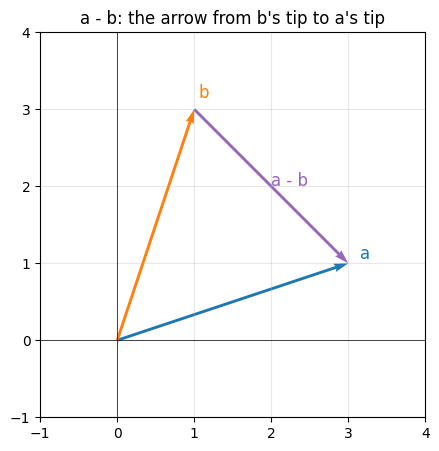

a - b = [ 2 -2]


In [6]:
a = np.array([3, 1])
b = np.array([1, 3])
d = a - b

fig, ax = plt.subplots(figsize=(5, 5))

# a and b from the origin
ax.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='tab:blue')
ax.text(a[0]*1.05, a[1]*1.05, "a", color='tab:blue', fontsize=12)
ax.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='tab:orange')
ax.text(b[0]*1.05, b[1]*1.05, "b", color='tab:orange', fontsize=12)

# a - b drawn as an arrow starting at b's tip, ending at a's tip
ax.quiver(b[0], b[1], d[0], d[1], angles='xy', scale_units='xy', scale=1,
          color='tab:purple')
ax.text(b[0] + d[0]*0.5, b[1] + d[1]*0.5, "a - b", color='tab:purple', fontsize=12)

lim = max(abs(a).max(), abs(b).max()) + 1
ax.set_xlim(-1, lim); ax.set_ylim(-1, lim)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title("a - b: the arrow from b's tip to a's tip")
plt.show()

print("a - b =", d)

# Answer to "does a-b point from a to b, or b to a?":
# It points FROM b TO a (starts at b's tip, ends at a's tip).
# If you wanted the arrow from a to b instead, that's b - a = -(a - b),
# i.e. the exact same length, opposite direction.